In [11]:
# 이미지 감지 후 결과 출력
!pip install ultralytics opencv-python


In [12]:
import cv2
from ultralytics import YOLO
import numpy as np
import os

model = YOLO('yolo11n.pt')


In [13]:
image_path = 'image1.jpg'
image = cv2.imread(image_path)
if image is None:
  print('이미지를 읽을 수 없어요')
  exit()

results = model(image)
print(results)


0: 416x640 2 persons, 251.3ms
Speed: 8.6ms preprocess, 251.3ms inference, 2.8ms postprocess per image at shape (1, 3, 416, 640)
[ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange'

감지된 사람 수는 2명


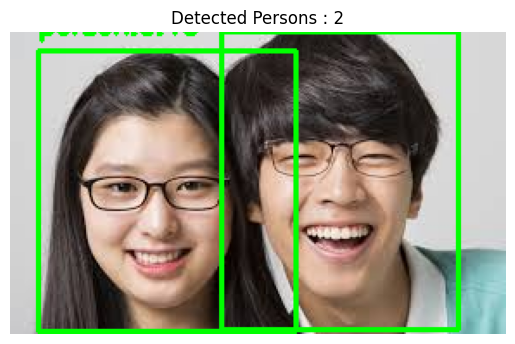

감지된 결과 yolo3output.jpg로 저장 성공


In [14]:
# 원본 이미지 별도 기억
import matplotlib.pyplot as plt

original = image.copy()

person_count = 0

for result in results:
    for box in result.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])  # 좌표 반환
        label = result.names[int(box.cls[0])] # 라벨명 반환
        confidence = box.conf[0].item() # 신뢰도 반환

        if label.lower() == 'person':
            person_count += 1

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

print(f'감지된 사람 수는 {person_count}명')

# 시각화
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'Detected Persons : {person_count}')
plt.show()

# 바운딩 박스 결과를 이미지로 저장
output_path = 'yolo3output.jpg'
cv2.imwrite(output_path, image)
print(f'감지된 결과 {output_path}로 저장 성공')

In [16]:
print('바운딩 박스 좌표 출력')
for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y2, x1, y2 = map(int, box.xyxy[0])
    print(f'라벨:{label} : 신뢰도:{confidence}, 좌표=[({x1},{y1}),({x2},{y2})]')


바운딩 박스 좌표 출력
라벨:person : 신뢰도:0.8158668279647827, 좌표=[(259,11),(165,172)]
라벨:person : 신뢰도:0.46297913789749146, 좌표=[(165,11),(165,173)]


In [18]:
from torch._higher_order_ops.flex_attention import flex_attention_functionalize
# 신회도 높은 객체만 필터링 (예:70%이상)
for idx, result in enumerate(results):
  print(f'이미지 {idx}번째 결과 : ')
  fount = False

  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y2, x1, y2 = map(int, box.xyxy[0])

    if confidence >= 0.7:
      print(f' - {label} {confidence:.2f}')
      found = True
  if not found:
    print(' - 신뢰도 70%이상 객체가 없어요')



이미지 0번째 결과 : 
 - person 0.82


In [25]:
import os

# 바운딩 박스 내부 객체 저장
for idx, result in enumerate(results):
    for j, box in enumerate(result.boxes):
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 이미지에서 ROI(Region Of interest:관심 영역) 추출
        cropped = image[y1:y2, x1:x2]     # 배열 슬라이싱(행방향, 열방향으로 자르기)

        # 저장 파일 만들기
        crop_path = f'crop_{idx}_{j}_{label}_{confidence:.2f}.jpg'
        cv2.imwrite(crop_path, cropped)
        print(f'{crop_path} 저장 성공')

# crop 폴더 생성
os.makedirs('crop', exist_ok=True)

# 바운딩 박스 내부 객체 저장 2 -> 바운딩 박스 없이 이미지만 저장
for idx, result in enumerate(results):
    for j, box in enumerate(result.boxes):
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()
        x1, y1, x2, y2 = map(int, box.xyxy[0])

        # 이미지에서 ROI(Region Of interest:관심 영역) 추출
        cropped = original[y1:y2, x1:x2]     # 배열 슬라이싱(행방향, 열방향으로 자르기)

        # 저장 파일 만들기
        crop_path = os.path.join('crop', f'crop_{idx}_{j}_{label}_{confidence:.2f}.jpg')

        cv2.imwrite(crop_path, cropped)
        print(f'{crop_path} 저장(바운딩박스x) 성공')

crop_0_0_person_0.82.jpg 저장 성공
crop_0_1_person_0.46.jpg 저장 성공
crop/crop_0_0_person_0.82.jpg 저장(바운딩박스x) 성공
crop/crop_0_1_person_0.46.jpg 저장(바운딩박스x) 성공


person = > 1: 중심좌표 = (190, 86, 신뢰도0.8158668279647827)
person = > 2: 중심좌표 = (90, 92, 신뢰도0.46297913789749146)


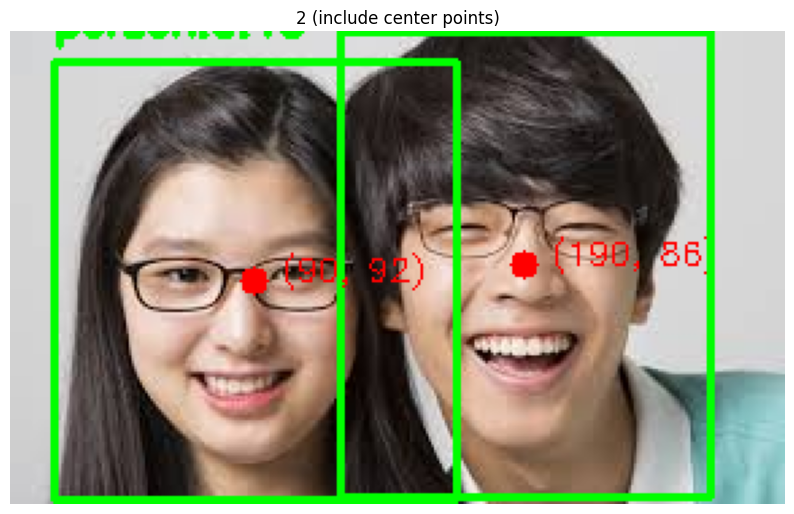

In [27]:
# 감지된 객체에 중심 좌표 출력
person_count = 0

for result in results:
  for box in result.boxes:
    label = result.names[int(box.cls[0])]
    confidence = box.conf[0].item()
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # 중심 좌표
    center_x = (x1 + x2) // 2
    center_y = (y1 + y2) // 2

    if label.lower() == 'person':
      person_count += 1
      print(f'person = > {person_count}: 중심좌표 = ({center_x}, {center_y}, 신뢰도{confidence})')

      # 중심점을 원으로 그리기
      cv2.circle(image, (center_x, center_y), 5, (0, 0, 255), -1)

      coord_text = f'({center_x}, {center_y})'
      cv2.putText(image, coord_text, (center_x + 10, center_y),
                  cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,255), 1)

      cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
      cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title(f'{person_count} (include center points)')
plt.show()


0: 640x640 2 persons, 245.1ms
1: 640x640 3 persons, 1 handbag, 245.1ms
Speed: 10.5ms preprocess, 245.1ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 640)

이미지 0 (image1.jpg) 결과 : 
 - person(0.78)
 - person(0.43)

이미지 1 (image2.jpg) 결과 : 
 - person(0.83)
 - person(0.73)
 - handbag(0.45)


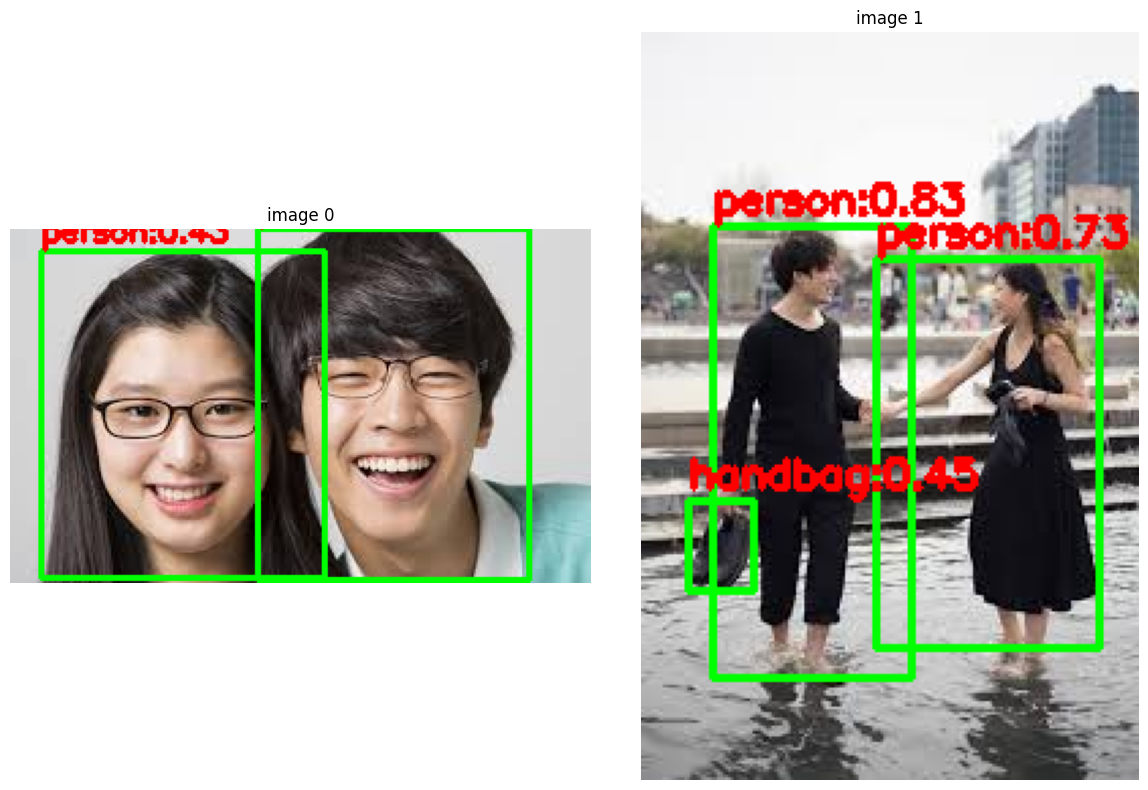

In [28]:
# 복수 이미지 처리
image_paths = ['image1.jpg', 'image2.jpg']
results = model(image_paths)

# 시각화
fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 8))

for idx, (result, image_path) in enumerate(zip(results, image_paths)):
    print(f'\n이미지 {idx} ({image_path}) 결과 : ')
    found = False

    # 원본 이미지 읽기
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for box in result.boxes:
        label = result.names[int(box.cls[0])]
        confidence = box.conf[0].item()

        if confidence >= 0.4:
            print(f' - {label}({confidence:.2f})')
            found = True

            x1, y1, x2, y2 = map(int, box.xyxy[0])
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(image, f'{label}:{confidence:.2f}', (x1, y1 - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    if not found:
        print('신뢰도 40% 이상 감지된 객체가 없어요')

    axes[idx].imshow(image)
    axes[idx].set_title(f'image {idx}')
    axes[idx].axis('off')

plt.tight_layout()
plt.show()